# # Week 1 Assignment
# Data Preprocessing & Exploratory Data Analysis
# Titanic Dataset
#
# Internship:
# AnalystLab Africa Machine Learning Internship
#
# Objective:
# Analyze passenger information and identify
# factors affecting survival.
#
# Target Variable:
# Survived

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [4]:
from google.colab import files

uploaded = files.upload()

Saving Titanic-Dataset.csv to Titanic-Dataset.csv


In [5]:
df = pd.read_csv("/content/Titanic-Dataset.csv")

In [6]:
sns.set_style("whitegrid")

plt.rcParams["figure.figsize"]=(8,5)

In [7]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


Dataset Overview

The Titanic dataset contains passenger information including demographic details, ticket information, travel class, and survival status. The goal of this analysis is to preprocess the dataset, perform exploratory data analysis (EDA), and prepare the data for future machine learning model development.

In [8]:
df.shape

(891, 12)

In [9]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [10]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [12]:
df.describe(include="all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [13]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [14]:
df.duplicated().sum()

np.int64(0)

Initial Inspection Report

The Titanic dataset contains passenger information with both numerical and categorical features.

During the initial inspection:

The dataset dimensions were examined.
Data types for each feature were identified.
Missing values were detected in some columns.
Duplicate records were checked.
Summary statistics were generated for numerical and categorical variables.

This inspection provides an overview of the dataset's quality before preprocessing.

# Data Preprocessing

In [15]:
# Check missing values in each column
missing_values = df.isnull().sum()

print(missing_values)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [16]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percentage
})

missing_df

,Missing Values,Percentage
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
Age,177,19.865320
SibSp,0,0.000000
Parch,0,0.000000
Ticket,0,0.000000
Fare,0,0.000000


In [17]:
df["Age"].fillna(df["Age"].median(), inplace=True)

/tmp/ipykernel_1537/2097741607.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)


In [ ]:
Age contains 177 missing values (approximately 20% of the dataset). Since Age is a numerical feature and may contain outliers, the median value was used instead of the mean.
 Median is more robust against extreme values and provides a better estimate for missing ages.

In [20]:
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

/tmp/ipykernel_1537/122844256.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)


In [ ]:
The Embarked column contains only two missing values.
 Since it is a categorical variable, the missing entries were replaced using the mode (most frequent category).

In [21]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [22]:
duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 0


In [23]:
df.drop_duplicates(inplace=True)

In [ ]:
The dataset was examined for duplicate records.
 No duplicate rows were found; therefore, no records were removed.

#outliers detection

In [24]:
# Select numerical columns
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

print("Numerical Columns:")
print(numerical_columns)

Numerical Columns:
Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')


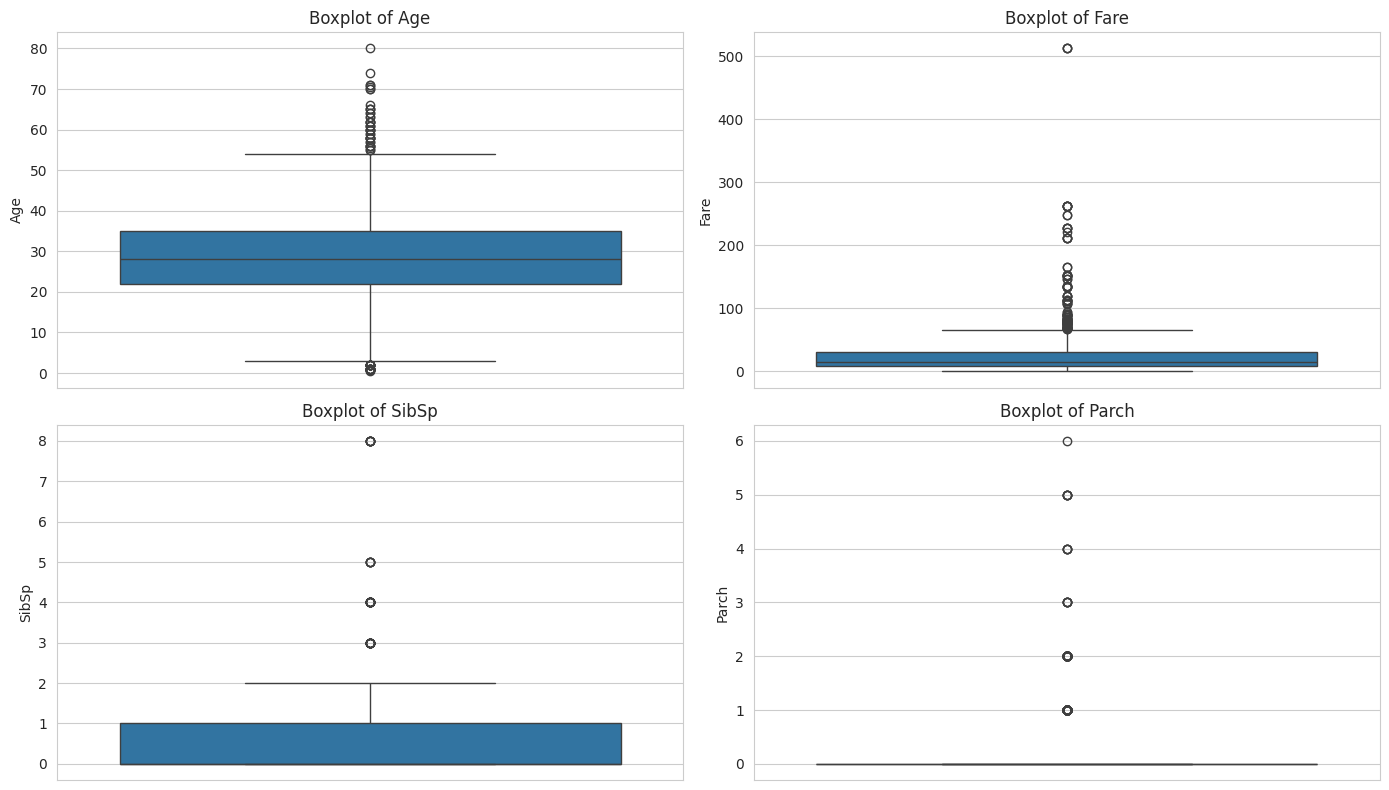

In [25]:
columns_to_plot = ["Age", "Fare", "SibSp", "Parch"]

plt.figure(figsize=(14,8))

for i, column in enumerate(columns_to_plot):
    plt.subplot(2,2,i+1)
    sns.boxplot(y=df[column])
    plt.title(f"Boxplot of {column}")

plt.tight_layout()
plt.show()

In [31]:
def detect_outliers(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower) | (data[column] > upper)]

    print(f"{column}")
    print(f"Number of Outliers: {len(outliers)}")
    print("-"*40)

In [32]:
for col in columns_to_plot:
    detect_outliers(df, col)

Age
Number of Outliers: 66
----------------------------------------
Fare
Number of Outliers: 116
----------------------------------------
SibSp
Number of Outliers: 46
----------------------------------------
Parch
Number of Outliers: 213
----------------------------------------


## Outlier Treatment

Outliers were identified using boxplots and the Interquartile Range (IQR) method.

The numerical features Age, Fare, SibSp, and Parch were analyzed.

Although several outliers were detected, they were retained because they represent genuine passenger characteristics rather than data entry errors. For example, high Fare values correspond to first-class passengers, while larger SibSp and Parch values represent large families traveling together.

Removing these observations could reduce valuable information and negatively impact future machine learning models.

In [33]:
# Display categorical columns
categorical_columns = df.select_dtypes(include=["object"]).columns

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index(['Name', 'Sex', 'Ticket', 'Embarked'], dtype='object')


In [34]:
df.drop(["PassengerId", "Name", "Ticket"], axis=1, inplace=True)

print(df.head())

   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0         0       3    male  22.0      1      0   7.2500        S
1         1       1  female  38.0      1      0  71.2833        C
2         1       3  female  26.0      0      0   7.9250        S
3         1       1  female  35.0      1      0  53.1000        S
4         0       3    male  35.0      0      0   8.0500        S


## Feature Selection

PassengerId, Name, and Ticket were removed because they do not provide meaningful predictive information for machine learning models.

- PassengerId is only a unique identifier.
- Name is unique for almost every passenger.
- Ticket values are mostly unique and do not contain consistent patterns useful for prediction.

#Label Encoding

In [35]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["Sex"] = label_encoder.fit_transform(df["Sex"])

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,S
1,1,1,0,38.0,1,0,71.2833,C
2,1,3,0,26.0,0,0,7.9250,S
3,1,1,0,35.0,1,0,53.1000,S
4,0,3,1,35.0,0,0,8.0500,S


In [36]:
print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

{'female': np.int64(0), 'male': np.int64(1)}


In [ ]:
The Sex column contains only two categories.
 Label Encoding was applied to convert categorical values into numerical values while preserving information.

In [37]:
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,False,True
1,1,1,0,38.0,1,0,71.2833,False,False
2,1,3,0,26.0,0,0,7.9250,False,True
3,1,1,0,35.0,1,0,53.1000,False,True
4,0,3,1,35.0,0,0,8.0500,False,True


In [ ]:
The Embarked column contains more than two categories. One-Hot Encoding was applied to avoid introducing an artificial order among categories.
The first category was dropped to reduce multicollinearity.

In [38]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    int64  
 3   Age         891 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Fare        891 non-null    float64
 7   Embarked_Q  891 non-null    bool   
 8   Embarked_S  891 non-null    bool   
dtypes: bool(2), float64(2), int64(5)
memory usage: 50.6 KB
None


In [39]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked_Q', 'Embarked_S'],
      dtype='object')

In [40]:
scale_columns = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[scale_columns] = scaler.fit_transform(df[scale_columns])

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,0.827377,1,-0.565736,0.432793,-0.473674,-0.502445,False,True
1,1,-1.566107,0,0.663861,0.432793,-0.473674,0.786845,False,False
2,1,0.827377,0,-0.258337,-0.474545,-0.473674,-0.488854,False,True
3,1,-1.566107,0,0.433312,0.432793,-0.473674,0.420730,False,True
4,0,0.827377,1,0.433312,-0.474545,-0.473674,-0.486337,False,True


In [42]:
df.describe()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
count,891.000000,8.910000e+02,891.000000,8.910000e+02,8.910000e+02,8.910000e+02,8.910000e+02
mean,0.383838,-8.772133e-17,0.647587,2.272780e-16,4.386066e-17,5.382900e-17,3.987333e-18
std,0.486592,1.000562e+00,0.477990,1.000562e+00,1.000562e+00,1.000562e+00,1.000562e+00
min,0.000000,-1.566107e+00,0.000000,-2.224156e+00,-4.745452e-01,-4.736736e-01,-6.484217e-01
25%,0.000000,-3.693648e-01,0.000000,-5.657365e-01,-4.745452e-01,-4.736736e-01,-4.891482e-01
50%,0.000000,8.273772e-01,1.000000,-1.046374e-01,-4.745452e-01,-4.736736e-01,-3.573909e-01
75%,1.000000,8.273772e-01,1.000000,4.333115e-01,4.327934e-01,-4.736736e-01,-2.424635e-02
max,1.000000,8.273772e-01,1.000000,3.891554e+00,6.784163e+00,6.974147e+00,9.667167e+00


# Feature Scaling

StandardScaler was applied to numerical features including Pclass, Age, SibSp, Parch, and Fare.

Feature scaling ensures that numerical variables are measured on a similar scale, preventing features with larger values from dominating the machine learning model.

The target variable (Survived) and one-hot encoded variables were not scaled because they already represent categorical information.

In [45]:
df.to_csv("Titanic_Cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [46]:
from google.colab import files

files.download("Titanic_Cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Exploratory Data Analysis (EDA)

In [47]:
# Summary statistics
df.describe()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
count,891.000000,8.910000e+02,891.000000,8.910000e+02,8.910000e+02,8.910000e+02,8.910000e+02
mean,0.383838,-8.772133e-17,0.647587,2.272780e-16,4.386066e-17,5.382900e-17,3.987333e-18
std,0.486592,1.000562e+00,0.477990,1.000562e+00,1.000562e+00,1.000562e+00,1.000562e+00
min,0.000000,-1.566107e+00,0.000000,-2.224156e+00,-4.745452e-01,-4.736736e-01,-6.484217e-01
25%,0.000000,-3.693648e-01,0.000000,-5.657365e-01,-4.745452e-01,-4.736736e-01,-4.891482e-01
50%,0.000000,8.273772e-01,1.000000,-1.046374e-01,-4.745452e-01,-4.736736e-01,-3.573909e-01
75%,1.000000,8.273772e-01,1.000000,4.333115e-01,4.327934e-01,-4.736736e-01,-2.424635e-02
max,1.000000,8.273772e-01,1.000000,3.891554e+00,6.784163e+00,6.974147e+00,9.667167e+00


## Univariate Analysis

Univariate analysis focuses on examining each feature individually to understand its distribution, central tendency, spread, and potential anomalies before model development.

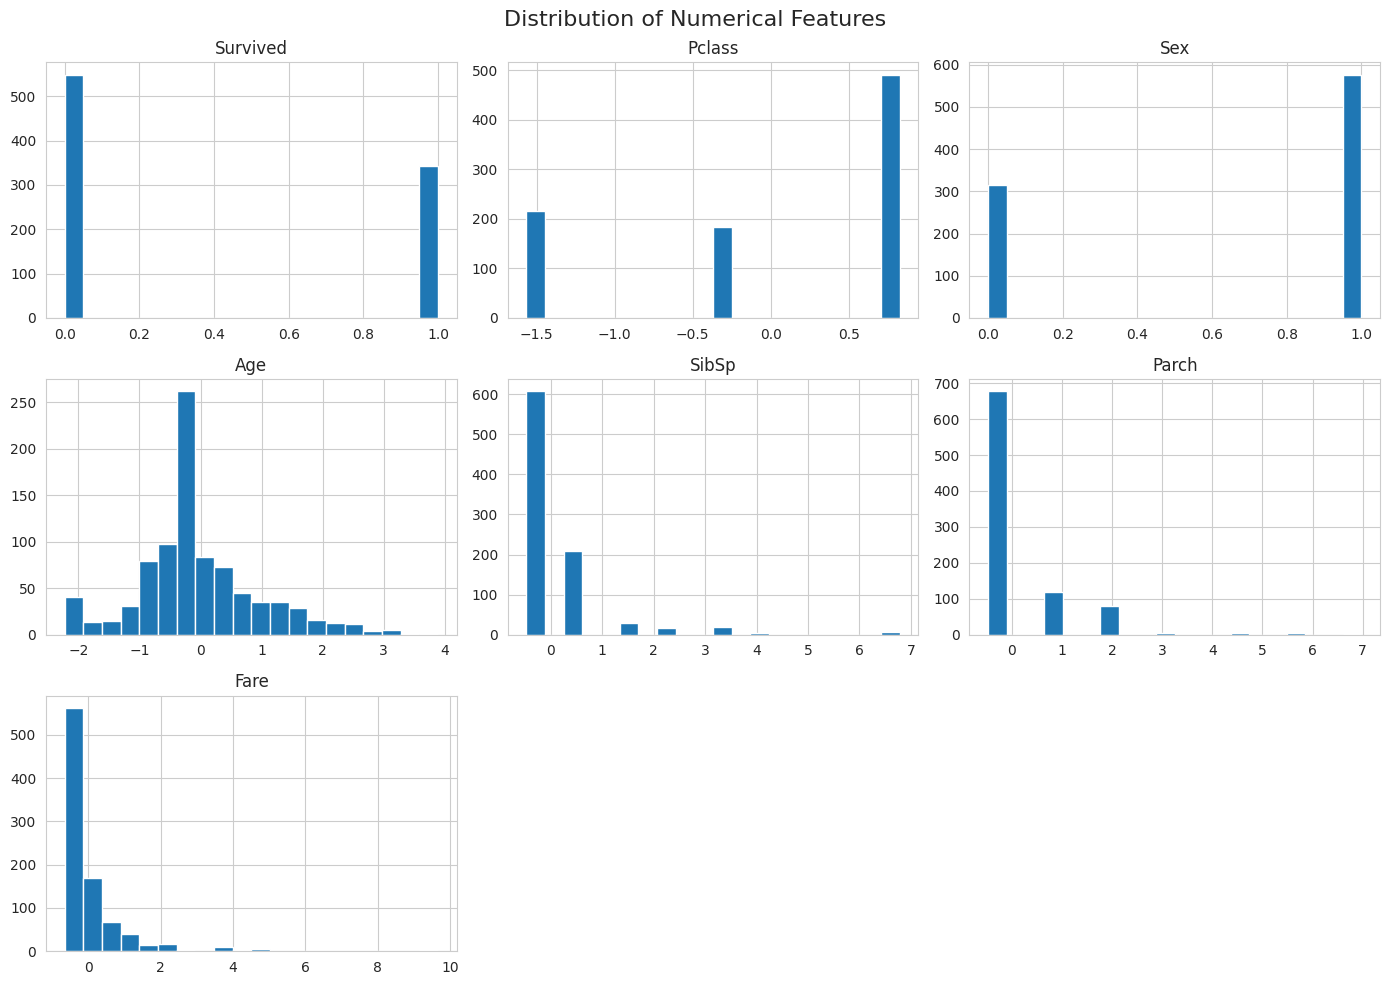

In [48]:
df.hist(figsize=(14,10), bins=20)

plt.suptitle("Distribution of Numerical Features", fontsize=16)

plt.tight_layout()

plt.show()

In [ ]:
Observations:

• Most passengers belong to lower passenger classes.

• Age is approximately centered around the median after preprocessing.

• Fare remains right-skewed despite scaling due to naturally expensive tickets.

• SibSp and Parch indicate that most passengers traveled with very few family members.

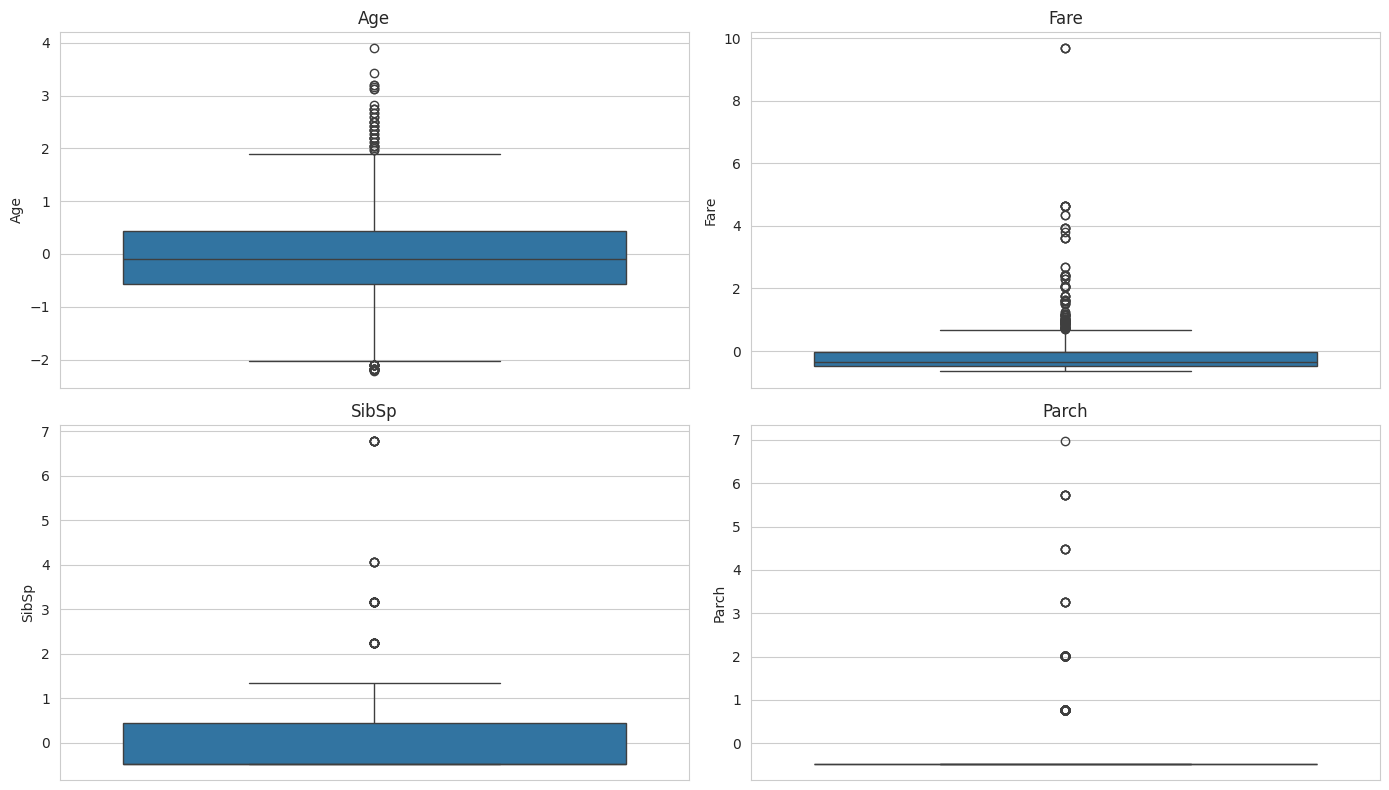

In [49]:
plt.figure(figsize=(14,8))

columns = ["Age","Fare","SibSp","Parch"]

for i,col in enumerate(columns):
    plt.subplot(2,2,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()

plt.show()

In [ ]:
Boxplots show that Fare contains several extreme values. These values were retained because they represent genuine first-class passenger fares rather than data entry errors.

Age, SibSp, and Parch also contain some outliers, but these observations represent actual passengers and were therefore retained.

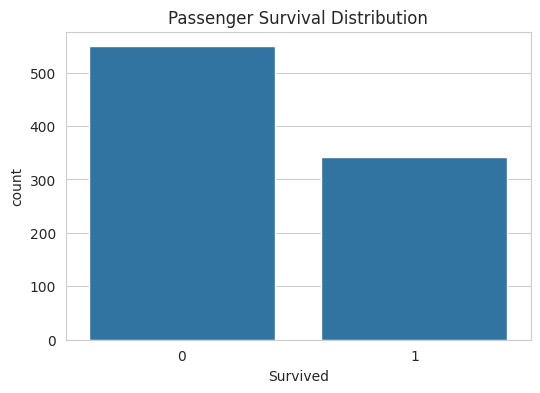

In [50]:
plt.figure(figsize=(6,4))

sns.countplot(x="Survived", data=df)

plt.title("Passenger Survival Distribution")

plt.show()

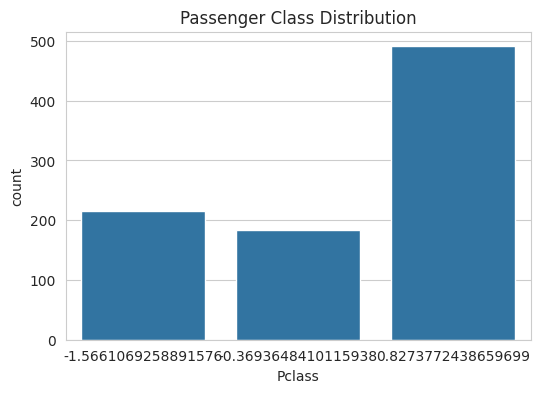

In [51]:
plt.figure(figsize=(6,4))

sns.countplot(x="Pclass", data=df)

plt.title("Passenger Class Distribution")

plt.show()

In [52]:
print(label_encoder.classes_)

['female' 'male']


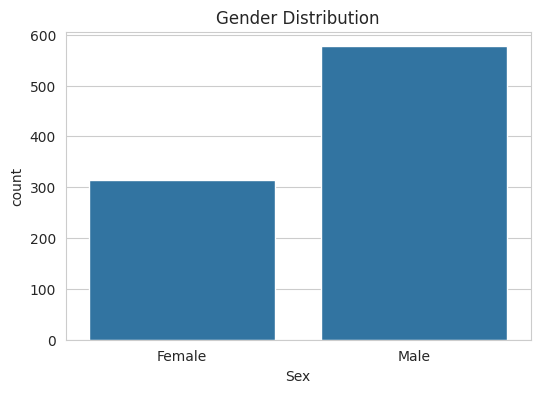

In [53]:
plt.figure(figsize=(6,4))

sns.countplot(x="Sex", data=df)

plt.title("Gender Distribution")

plt.xticks([0,1],["Female","Male"])

plt.show()

In [ ]:
#Bivariate Analysis

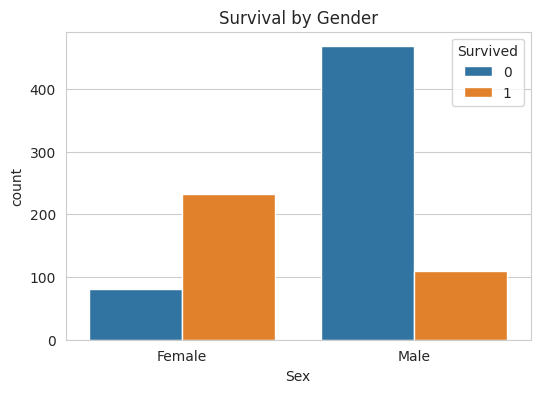

In [54]:
plt.figure(figsize=(6,4))

sns.countplot(x="Sex", hue="Survived", data=df)

plt.xticks([0,1],["Female","Male"])

plt.title("Survival by Gender")

plt.show()

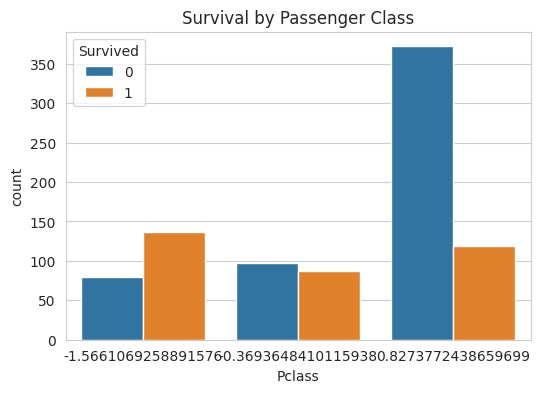

In [55]:
plt.figure(figsize=(6,4))

sns.countplot(x="Pclass", hue="Survived", data=df)

plt.title("Survival by Passenger Class")

plt.show()

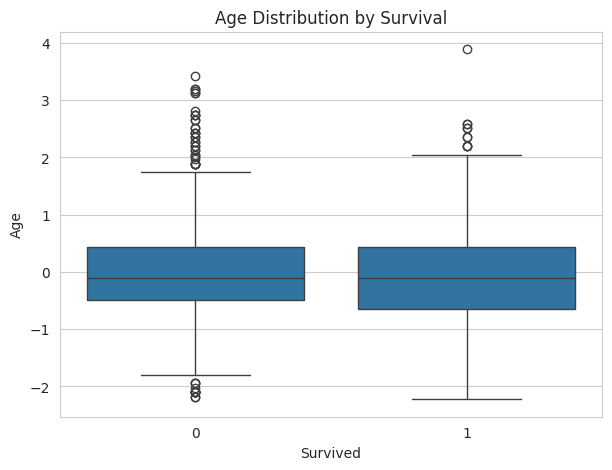

In [56]:
plt.figure(figsize=(7,5))

sns.boxplot(x="Survived", y="Age", data=df)

plt.title("Age Distribution by Survival")

plt.show()

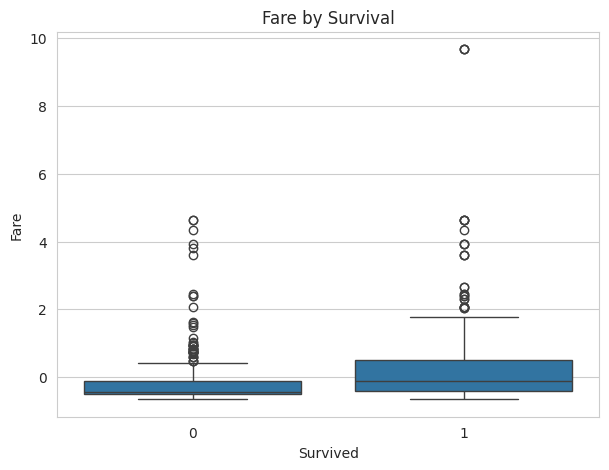

In [57]:
plt.figure(figsize=(7,5))

sns.boxplot(x="Survived", y="Fare", data=df)

plt.title("Fare by Survival")

plt.show()

In [ ]:
• Female passengers survived more often.

• First-class passengers had higher survival rates.

• Higher ticket fares were associated with better survival.

• Most passengers traveled in third class.

• Age showed a weaker relationship with survival compared to gender and passenger class.

Correlation Analysis & Feature Understanding

In [58]:
# Correlation matrix
correlation_matrix = df.corr()

correlation_matrix

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
Survived,1.000000,-0.338481,-0.543351,-0.064910,-0.035322,0.081629,0.257307,0.003650,-0.149683
Pclass,-0.338481,1.000000,0.131900,-0.339898,0.083081,0.018443,-0.549500,0.221009,0.074053
Sex,-0.543351,0.131900,1.000000,0.081163,-0.114631,-0.245489,-0.182333,-0.074115,0.119224
Age,-0.064910,-0.339898,0.081163,1.000000,-0.233296,-0.172482,0.096688,-0.031415,-0.006729
SibSp,-0.035322,0.083081,-0.114631,-0.233296,1.000000,0.414838,0.159651,-0.026354,0.068734
Parch,0.081629,0.018443,-0.245489,-0.172482,0.414838,1.000000,0.216225,-0.081228,0.060814
Fare,0.257307,-0.549500,-0.182333,0.096688,0.159651,0.216225,1.000000,-0.117216,-0.162184
Embarked_Q,0.003650,0.221009,-0.074115,-0.031415,-0.026354,-0.081228,-0.117216,1.000000,-0.499421
Embarked_S,-0.149683,0.074053,0.119224,-0.006729,0.068734,0.060814,-0.162184,-0.499421,1.000000


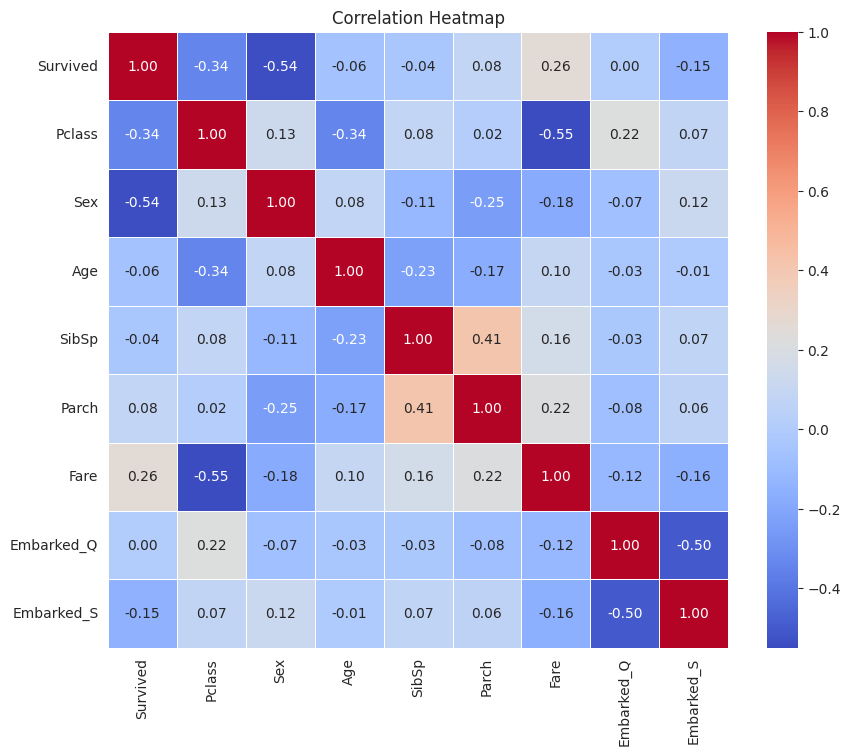

In [59]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## Correlation Analysis

A correlation matrix was generated to examine relationships between numerical variables.

The heatmap provides a visual representation of positive and negative correlations between features. This helps identify variables that may contribute significantly to future machine learning models.

In [ ]:
Strong Positive Correlations

• Fare shows a positive relationship with survival.

• Passenger class and fare are moderately related.

• SibSp and Parch show a moderate positive relationship because family members often travel together.

# The features most likely to influence survival prediction are:

• Sex

• Passenger Class

• Fare

• Age (moderate influence)

Summary

# Machine Learning Readiness Summary

The Titanic dataset has been successfully prepared for machine learning model development.

Data preprocessing steps completed include:

• Missing values were handled using Median (Age) and Mode (Embarked).

• The Cabin column was removed due to excessive missing values.

• No duplicate records were found.

• Outliers were identified using boxplots and the IQR method. Genuine observations were retained.

• Label Encoding was applied to the Sex column.

• One-Hot Encoding was applied to the Embarked column.

• StandardScaler was used to normalize numerical features.

The dataset is now clean, transformed, and suitable for machine learning algorithms.

# Key Insights

1. Female passengers had a significantly higher survival rate than male passengers.

2. First-class passengers were more likely to survive than passengers in lower classes.

3. Fare shows considerable variation, with higher-paying passengers generally having better survival rates.

4. Most passengers traveled alone or with a small family, as indicated by the SibSp and Parch distributions.

5. After preprocessing, the dataset contains no missing values or duplicate records and is ready for machine learning model development.

In [60]:
print("Final Dataset Shape:", df.shape)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Records:", df.duplicated().sum())

df.head()

Final Dataset Shape: (891, 9)

Missing Values
Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked_Q    0
Embarked_S    0
dtype: int64

Duplicate Records: 116


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,0.827377,1,-0.565736,0.432793,-0.473674,-0.502445,False,True
1,1,-1.566107,0,0.663861,0.432793,-0.473674,0.786845,False,False
2,1,0.827377,0,-0.258337,-0.474545,-0.473674,-0.488854,False,True
3,1,-1.566107,0,0.433312,0.432793,-0.473674,0.420730,False,True
4,0,0.827377,1,0.433312,-0.474545,-0.473674,-0.486337,False,True
